In [18]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [19]:
col_names = ['zone_id', 'pickup_hour', 'pickup_hourofday', 'pickup_dayofmonth', 'pickup_dayofweek', 'pickup_month', 'pickup_quarter', 'is_holiday', 'trip_count', 'avg_fare', 'total_revenue', 'load_timestamp', 'update_timestamp']

df = pd.read_csv('data/nyc_taxi_data_2024_2025.csv', names=col_names, header=None)

In [20]:
df = df.copy().iloc[:,:-2]

In [21]:
df.head()

,zone_id,pickup_hour,pickup_hourofday,pickup_dayofmonth,pickup_dayofweek,pickup_month,pickup_quarter,is_holiday,trip_count,avg_fare,total_revenue
0,102,2024-05-11 07:00:00.000,7,11,6,5,2,0,1,48.50,55.94
1,82,2024-06-01 19:00:00.000,19,1,6,6,2,0,1,20.50,32.00
2,112,2024-03-02 09:00:00.000,9,2,6,3,1,0,1,39.50,41.00
3,130,2024-03-21 14:00:00.000,14,21,4,3,1,0,1,43.81,45.31
4,82,2024-01-10 08:00:00.000,8,10,3,1,1,0,1,36.50,38.00


In [56]:
df_ts = df[['pickup_hour', 'trip_count', 'zone_id']]

In [57]:
df_ts['pickup_hour']=pd.to_datetime(df_ts['pickup_hour'])

In [58]:
df_ts.sort_values(['zone_id', 'pickup_hour'], inplace=True)

In [59]:
df_ts.set_index('pickup_hour', inplace=True)

In [73]:
pd.DataFrame(df_ts['zone_id'].value_counts()).head()

,count
zone_id,
48,16799
186,16799
79,16797
100,16795
68,16792


<Axes: xlabel='pickup_hour'>

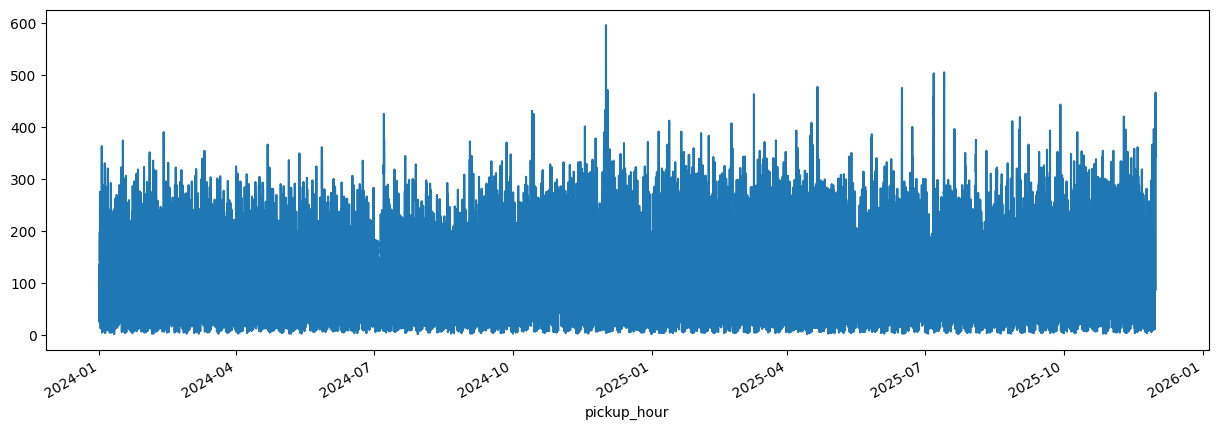

In [62]:
df_ts[df_ts['zone_id']==186]['trip_count'].plot(figsize=(15,5))

<Axes: xlabel='pickup_hour'>

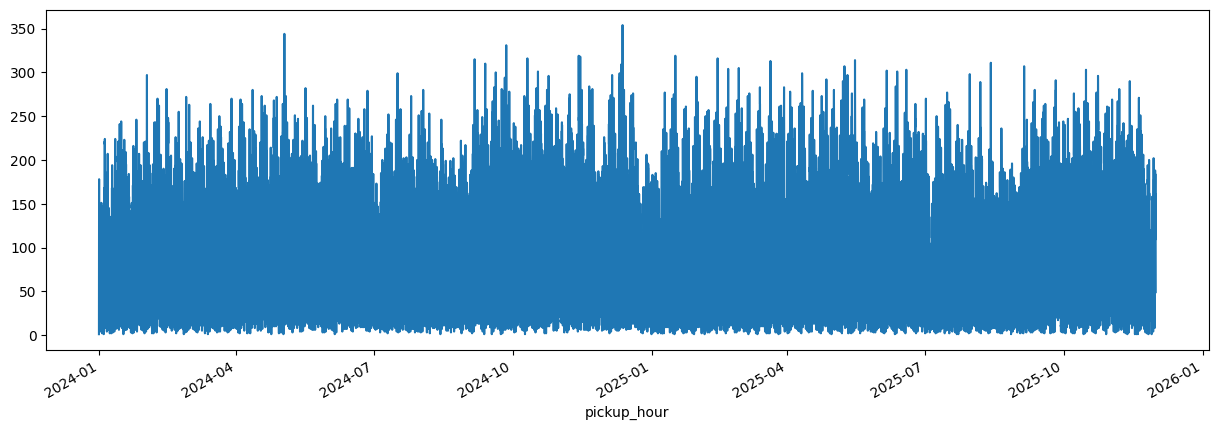

In [74]:
df_ts[df_ts['zone_id']==68]['trip_count'].plot(figsize=(15,5))

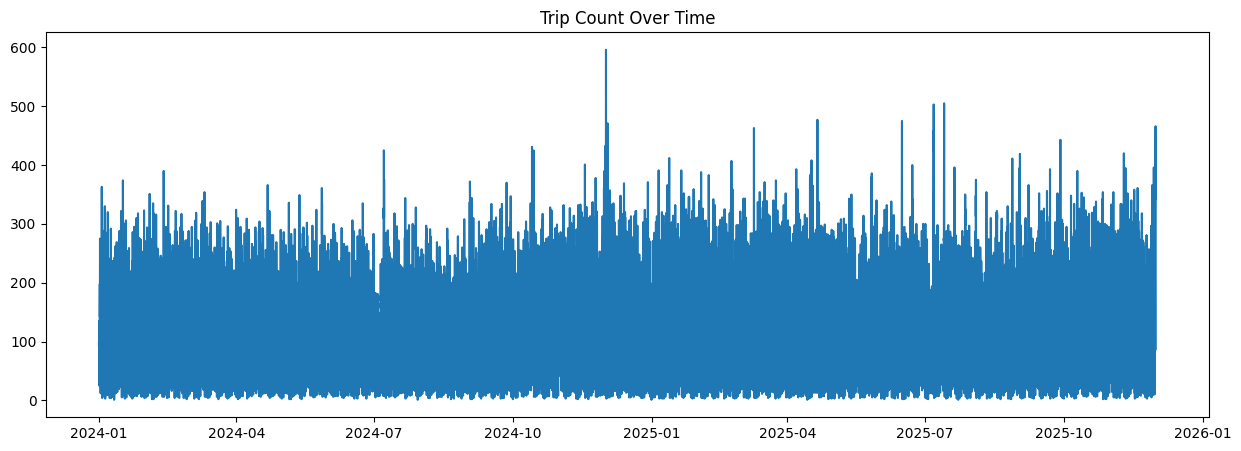

In [85]:
zone_df = df_ts[df_ts["zone_id"] == 186]   # pick one zone for testing

plt.figure(figsize=(15,5))
plt.plot(zone_df.index, zone_df["trip_count"])
plt.title("Trip Count Over Time")
plt.show()

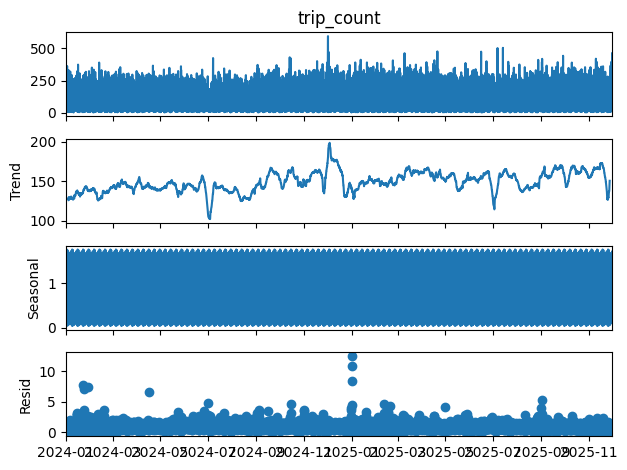

In [97]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(zone_df["trip_count"], model="multiplicative", period=168)
decomp.plot()
plt.show()

<Axes: xlabel='pickup_hour'>

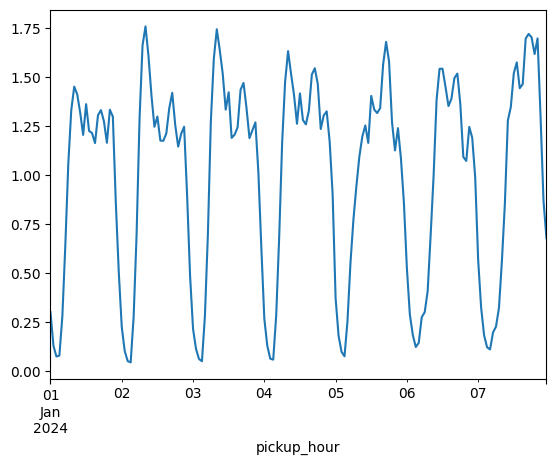

In [98]:
decomp.seasonal[:168].plot()

In [96]:
seasonal_decompose(df['trip_count'], model='multiplicative', period=168)

In [99]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(zone_df["trip_count"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -13.74765385684766
p-value: 1.0650729546515762e-25


In [101]:
zone_df["diff"] = zone_df["trip_count"].diff()

In [102]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(zone_df["diff"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -29.02812416955281
p-value: 0.0


In [103]:
zone_df["diff1"] = zone_df["diff"].diff()

In [104]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(zone_df["diff1"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -43.65473765217098
p-value: 0.0


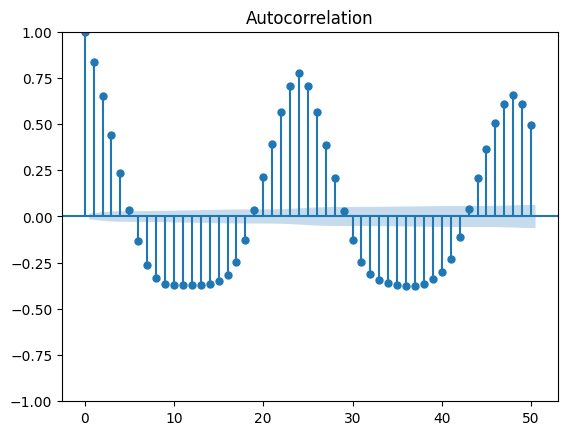

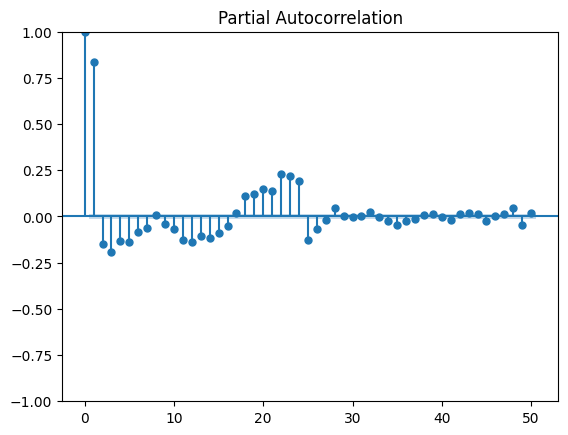

In [105]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(zone_df["trip_count"].dropna(), lags=50)
plt.show()

plot_pacf(zone_df["trip_count"].dropna(), lags=50)
plt.show()

In [106]:
df.head()

,zone_id,pickup_hour,pickup_hourofday,pickup_dayofmonth,pickup_dayofweek,pickup_month,pickup_quarter,is_holiday,trip_count,avg_fare,total_revenue
0,102,2024-05-11 07:00:00.000,7,11,6,5,2,0,1,48.50,55.94
1,82,2024-06-01 19:00:00.000,19,1,6,6,2,0,1,20.50,32.00
2,112,2024-03-02 09:00:00.000,9,2,6,3,1,0,1,39.50,41.00
3,130,2024-03-21 14:00:00.000,14,21,4,3,1,0,1,43.81,45.31
4,82,2024-01-10 08:00:00.000,8,10,3,1,1,0,1,36.50,38.00


In [108]:
df["lag_1"] = df.groupby("zone_id")["trip_count"].shift(1)
df["lag_24"] = df.groupby("zone_id")["trip_count"].shift(24)
df["lag_168"] = df.groupby("zone_id")["trip_count"].shift(168)

df = df.dropna()

In [111]:
df = df.drop(['avg_fare','total_revenue'], axis=1)

In [114]:
train = df[df["pickup_hour"] < "2025-08-31"]
test = df[df["pickup_hour"] >= "2025-08-31"]

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train["trip_count"],
                order=(1,1,1),
                seasonal_order=(1,1,1,24))

results = model.fit()
forecast = results.forecast(steps=len(test))

C:\Users\mukul\Desktop\Projects\nyc-taxi-demand-forecast\project_venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\mukul\Desktop\Projects\nyc-taxi-demand-forecast\project_venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [2]:
import pyarrow.parquet as pq

# Read the Parquet file into an Arrow Table
table = pq.read_table('data/yellow_tripdata_2025-01.parquet')

# Convert the table to a pandas DataFrame if needed later
df = table.to_pandas()

In [3]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


In [4]:
df.shape

(3475226, 20)